In [ ]:
# ================================
# Install Dependencies and Initial Setup
# ================================
!pip install -q tensorflow numpy pandas matplotlib seaborn scikit-learn opencv-python pillow krippendorff tqdm

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import cv2
import warnings
import shutil
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

# Sklearn + metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, mean_squared_error,
                           mean_absolute_error, cohen_kappa_score, classification_report, confusion_matrix)
from scipy.stats import pearsonr
import krippendorff

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("🚀 Setup Complete!")
print("TensorFlow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices())

🚀 Setup Complete!
TensorFlow version: 2.19.0
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ================================
# Mount Drive and Copy Dataset to Local Storage
# ================================
from google.colab import drive
drive.mount('/content/drive')

# Original paths (update these to match your structure)
IMAGES_DIR = "/content/drive/MyDrive/images"
ANNOTATIONS_DIR = "/content/drive/MyDrive/annotations"

# Verify original directories exist
if not os.path.exists(IMAGES_DIR):
    raise FileNotFoundError(f"❌ Images directory not found: {IMAGES_DIR}")
if not os.path.exists(ANNOTATIONS_DIR):
    raise FileNotFoundError(f"❌ Annotations directory not found: {ANNOTATIONS_DIR}")

print("✓ Original directories found:")
print(f"  Images: {IMAGES_DIR} ({len(os.listdir(IMAGES_DIR))} files)")
print(f"  Annotations: {ANNOTATIONS_DIR} ({len(os.listdir(ANNOTATIONS_DIR))} files)")

# Local storage directories for faster access
LOCAL_IMAGES = "/content/images"
LOCAL_ANNOTS = "/content/annotations"

os.makedirs(LOCAL_IMAGES, exist_ok=True)
os.makedirs(LOCAL_ANNOTS, exist_ok=True)

# Function to copy with progress bar
def copy_with_progress(src, dst):
    files = os.listdir(src)
    for f in tqdm(files, desc=f"Copying {os.path.basename(src)}", unit="files"):
        shutil.copy(os.path.join(src, f), dst)

# Copy to local storage
print("\n📁 Copying dataset to local storage for faster access...")
copy_with_progress(IMAGES_DIR, LOCAL_IMAGES)
copy_with_progress(ANNOTATIONS_DIR, LOCAL_ANNOTS)

# Update paths to local storage
IMAGES_DIR, ANNOTATIONS_DIR = LOCAL_IMAGES, LOCAL_ANNOTS
print("\n✅ Dataset copied to local storage successfully!")
print(f"  Local images: {len(os.listdir(IMAGES_DIR))} files")
print(f"  Local annotations: {len(os.listdir(ANNOTATIONS_DIR))} files")

Mounted at /content/drive
✓ Original directories found:
  Images: /content/drive/MyDrive/images (3999 files)
  Annotations: /content/drive/MyDrive/annotations (16013 files)

📁 Copying dataset to local storage for faster access...


Copying annotations: 100%|██████████| 16013/16013 [07:58<00:00, 33.44files/s] 


✅ Dataset copied to local storage successfully!
  Local images: 3999 files
  Local annotations: 16013 files


In [ ]:
# ================================
# Dataset Structure Exploration and Analysis
# ================================
def explore_dataset_structure(images_dir, annotations_dir):
    """Comprehensive dataset structure exploration"""

    print("🔍 EXPLORING DATASET STRUCTURE")
    print("="*70)

    # Get file lists
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    annotation_files = os.listdir(annotations_dir)

    print(f"📊 Dataset Overview:")
    print(f"  Total images: {len(image_files):,}")
    print(f"  Total annotation files: {len(annotation_files):,}")

    # Analyze annotation types
    exp_files = [f for f in annotation_files if '_exp.npy' in f]
    val_files = [f for f in annotation_files if '_val.npy' in f]
    aro_files = [f for f in annotation_files if '_aro.npy' in f]
    lnd_files = [f for f in annotation_files if '_lnd.npy' in f]

    print(f"\n📄 Annotation Files by Type:")
    print(f"  Expression (_exp.npy): {len(exp_files):,}")
    print(f"  Valence (_val.npy): {len(val_files):,}")
    print(f"  Arousal (_aro.npy): {len(aro_files):,}")
    print(f"  Landmarks (_lnd.npy): {len(lnd_files):,}")

    # Sample files for pattern analysis
    print(f"\n📁 Sample Files:")
    print("  Images:", sorted(image_files)[:5])
    print("  Expression:", sorted(exp_files)[:5])
    print("  Valence:", sorted(val_files)[:5])
    print("  Arousal:", sorted(aro_files)[:5])

    # Test annotation loading
    print(f"\n🧪 Testing Annotation Loading:")

    test_results = []
    for i, exp_file in enumerate(exp_files[:3]):
        try:
            exp_path = os.path.join(annotations_dir, exp_file)
            exp_data = np.load(exp_path, allow_pickle=True)

            # Extract actual value
            if hasattr(exp_data, 'item'):
                actual_value = exp_data.item()
            else:
                actual_value = exp_data

            test_results.append({
                'file': exp_file,
                'raw_data': str(exp_data),
                'extracted_value': actual_value,
                'data_type': type(actual_value).__name__,
                'valid': 0 <= actual_value <= 7 if isinstance(actual_value, (int, float)) else False
            })

            print(f"  ✅ {exp_file}: {actual_value} (type: {type(actual_value).__name__})")

        except Exception as e:
            test_results.append({
                'file': exp_file,
                'error': str(e),
                'valid': False
            })
            print(f"  ❌ {exp_file}: Error - {e}")

    return {
        'total_images': len(image_files),
        'total_annotations': len(annotation_files),
        'exp_files': len(exp_files),
        'val_files': len(val_files),
        'aro_files': len(aro_files),
        'test_results': test_results
    }

# Explore the dataset
print("Starting dataset exploration...")
dataset_info = explore_dataset_structure(IMAGES_DIR, ANNOTATIONS_DIR)

# Summary
if dataset_info['exp_files'] > 0:
    print(f"\n✅ Dataset appears valid!")
    print(f"   Complete annotation sets available: ~{min(dataset_info['exp_files'], dataset_info['val_files'], dataset_info['aro_files']):,}")
    print(f"   Ready to proceed with data loading...")
else:
    print(f"\n❌ No expression annotation files found!")
    print(f"   Please check your annotation file naming convention.")

Starting dataset exploration...
🔍 EXPLORING DATASET STRUCTURE
📊 Dataset Overview:
  Total images: 3,999
  Total annotation files: 16,013

📄 Annotation Files by Type:
  Expression (_exp.npy): 3,999
  Valence (_val.npy): 3,999
  Arousal (_aro.npy): 3,999
  Landmarks (_lnd.npy): 3,999

📁 Sample Files:
  Images: ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1001.jpg']
  Expression: ['0_exp.npy', '1001_exp.npy', '1002_exp.npy', '1003_exp.npy', '1007_exp.npy']
  Valence: ['0_val.npy', '1001_val.npy', '1002_val.npy', '1003_val.npy', '1007_val.npy']
  Arousal: ['0_aro.npy', '1001_aro.npy', '1002_aro.npy', '1003_aro.npy', '1007_aro.npy']

🧪 Testing Annotation Loading:
  ✅ 3039_exp.npy: 4 (type: str)
  ✅ 3285_exp.npy: 3 (type: str)
  ✅ 918_exp.npy: 7 (type: str)

✅ Dataset appears valid!
   Complete annotation sets available: ~3,999
   Ready to proceed with data loading...


In [ ]:
# ================================
# Smart Data Loading with Multiple Fallback Strategies
# ================================
IMG_SIZE = (224, 224)

def smart_load_dataset(images_dir, annotations_dir, max_samples=4000):
    """Advanced dataset loading with comprehensive error handling"""

    print("🚀 Starting Smart Dataset Loading...")
    print("="*50)

    # Get and sort image files
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    image_files.sort(key=lambda x: int(x.split('.')[0]) if x.split('.')[0].isdigit() else 0)

    # Get annotation file mappings
    annotation_files = os.listdir(annotations_dir)
    exp_files = {f.replace('_exp.npy', ''): f for f in annotation_files if '_exp.npy' in f}
    val_files = {f.replace('_val.npy', ''): f for f in annotation_files if '_val.npy' in f}
    aro_files = {f.replace('_aro.npy', ''): f for f in annotation_files if '_aro.npy' in f}

    print(f"📊 File Analysis:")
    print(f"  Images found: {len(image_files):,}")
    print(f"  Expression annotations: {len(exp_files):,}")
    print(f"  Valence annotations: {len(val_files):,}")
    print(f"  Arousal annotations: {len(aro_files):,}")

    def find_annotation_id(img_file):
        """Smart annotation ID matching with multiple strategies"""
        img_id = img_file.split('.')[0]

        # Strategy 1: Direct match
        if img_id in exp_files:
            return img_id

        # Strategy 2: Remove leading zeros
        if img_id.isdigit():
            img_id_no_zeros = str(int(img_id))
            if img_id_no_zeros in exp_files:
                return img_id_no_zeros

        # Strategy 3: Add leading zeros (try different padding)
        for pad_length in range(2, 8):
            if img_id.isdigit():
                padded_id = img_id.zfill(pad_length)
                if padded_id in exp_files:
                    return padded_id

        return None

    def safe_load_annotation(file_path):
        """Safely load annotation with multiple extraction strategies"""
        try:
            data = np.load(file_path, allow_pickle=True)

            # Strategy 1: Scalar value
            if np.isscalar(data):
                return data

            # Strategy 2: Extract using .item()
            if hasattr(data, 'item'):
                return data.item()

            # Strategy 3: First element of array
            if isinstance(data, np.ndarray) and data.size > 0:
                return data.flat[0]

            # Strategy 4: Dictionary extraction
            if isinstance(data, dict):
                for key in ['value', 'label', 'annotation', 'data', '0', 0]:
                    if key in data:
                        return data[key]

            return None

        except Exception as e:
            return None

    # Initialize data containers
    X, y_exp, y_val, y_aro = [], [], [], []

    # Tracking variables
    loaded_count = 0
    missing_annotations = 0
    invalid_data = 0
    image_errors = 0

    print(f"\n🔄 Loading samples (max: {max_samples:,})...")

    # Process images
    for img_file in tqdm(image_files, desc="Processing images"):
        if loaded_count >= max_samples:
            break

        # Find matching annotation ID
        ann_id = find_annotation_id(img_file)

        if ann_id is None or ann_id not in exp_files or ann_id not in val_files or ann_id not in aro_files:
            missing_annotations += 1
            continue

        try:
            # Load and process image
            img_path = os.path.join(images_dir, img_file)
            img = cv2.imread(img_path)

            if img is None:
                image_errors += 1
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)

            # Load annotations
            exp = safe_load_annotation(os.path.join(annotations_dir, exp_files[ann_id]))
            val = safe_load_annotation(os.path.join(annotations_dir, val_files[ann_id]))
            aro = safe_load_annotation(os.path.join(annotations_dir, aro_files[ann_id]))

            # Validate annotations
            if exp is None or val is None or aro is None:
                invalid_data += 1
                continue

            # Convert and validate data types
            try:
                exp = int(exp)
                val = float(val)
                aro = float(aro)
            except (ValueError, TypeError):
                invalid_data += 1
                continue

            # Validate ranges
            if not (0 <= exp <= 7):
                invalid_data += 1
                continue

            # Normalize regression values to [-1, 1] with tolerance
            val = np.clip(val, -1, 1)
            aro = np.clip(aro, -1, 1)

            # Add to dataset
            X.append(img)
            y_exp.append(exp)
            y_val.append(val)
            y_aro.append(aro)
            loaded_count += 1

            # Progress updates
            if loaded_count % 1000 == 0:
                print(f"  ✓ {loaded_count:,} samples loaded...")

        except Exception as e:
            image_errors += 1
            continue

    # Loading summary
    total_processed = len(image_files)
    print(f"\n📊 Loading Summary:")
    print(f"  Total images processed: {total_processed:,}")
    print(f"  Successfully loaded: {loaded_count:,}")
    print(f"  Missing annotations: {missing_annotations:,}")
    print(f"  Invalid data: {invalid_data:,}")
    print(f"  Image errors: {image_errors:,}")
    print(f"  Success rate: {loaded_count/total_processed*100:.1f}%")

    if loaded_count == 0:
        print("\n❌ CRITICAL ERROR: No samples loaded successfully!")
        print("Please check:")
        print("  1. File naming conventions")
        print("  2. Annotation file formats")
        print("  3. Data validity")
        return None, None, None, None

    # Convert to numpy arrays
    print(f"\n🔄 Converting to numpy arrays...")
    X = np.array(X, dtype="float32") / 255.0
    y_exp = to_categorical(np.array(y_exp), num_classes=8)
    y_val = np.array(y_val, dtype="float32")
    y_aro = np.array(y_aro, dtype="float32")

    print(f"\n✅ Dataset Loading Successful!")
    print(f"  Images shape: {X.shape}")
    print(f"  Expressions shape: {y_exp.shape}")
    print(f"  Valence shape: {y_val.shape}")
    print(f"  Arousal shape: {y_aro.shape}")

    # Class distribution analysis
    exp_labels = np.argmax(y_exp, axis=1)
    class_names = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']

    print(f"\n📈 Expression Class Distribution:")
    class_counts = np.bincount(exp_labels, minlength=8)
    for i, (name, count) in enumerate(zip(class_names, class_counts)):
        percentage = count / loaded_count * 100
        print(f"  {i}. {name:10s}: {count:4d} samples ({percentage:5.1f}%)")

    # Check for class balance
    min_class_size = np.min(class_counts)
    max_class_size = np.max(class_counts)
    balance_ratio = min_class_size / max_class_size if max_class_size > 0 else 0

    if balance_ratio > 0.8:
        print(f"  ✅ Well-balanced dataset (ratio: {balance_ratio:.2f})")
    elif balance_ratio > 0.5:
        print(f"  ⚠️  Moderately balanced dataset (ratio: {balance_ratio:.2f})")
    else:
        print(f"  ❌ Imbalanced dataset (ratio: {balance_ratio:.2f})")

    return X, y_exp, y_val, y_aro

# Load the dataset
X, y_exp, y_val, y_aro = smart_load_dataset(IMAGES_DIR, ANNOTATIONS_DIR, max_samples=4000)

# Set global flag for successful loading
DATASET_LOADED = X is not None and len(X) > 0

if DATASET_LOADED:
    print(f"\n🎉 DATASET READY FOR TRAINING!")
    print(f"   Total samples: {len(X):,}")
    print(f"   Classes with data: {np.sum(np.bincount(np.argmax(y_exp, axis=1)) > 0)}/8")
else:
    print(f"\n💥 DATASET LOADING FAILED!")
    print(f"   Please check your data format and file structure.")

🚀 Starting Smart Dataset Loading...
📊 File Analysis:
  Images found: 3,999
  Expression annotations: 3,999
  Valence annotations: 3,999
  Arousal annotations: 3,999

🔄 Loading samples (max: 4,000)...


Processing images:  28%|██▊       | 1115/3999 [00:01<00:02, 980.20it/s]

  ✓ 1,000 samples loaded...


Processing images:  53%|█████▎    | 2105/3999 [00:02<00:01, 952.71it/s]

  ✓ 2,000 samples loaded...


Processing images:  78%|███████▊  | 3131/3999 [00:03<00:00, 881.20it/s]

  ✓ 3,000 samples loaded...


Processing images: 100%|██████████| 3999/3999 [00:04<00:00, 976.91it/s] 



📊 Loading Summary:
  Total images processed: 3,999
  Successfully loaded: 3,999
  Missing annotations: 0
  Invalid data: 0
  Image errors: 0
  Success rate: 100.0%

🔄 Converting to numpy arrays...

✅ Dataset Loading Successful!
  Images shape: (3999, 224, 224, 3)
  Expressions shape: (3999, 8)
  Valence shape: (3999,)
  Arousal shape: (3999,)

📈 Expression Class Distribution:
  0. Neutral   :  500 samples ( 12.5%)
  1. Happy     :  500 samples ( 12.5%)
  2. Sad       :  500 samples ( 12.5%)
  3. Surprise  :  500 samples ( 12.5%)
  4. Fear      :  500 samples ( 12.5%)
  5. Disgust   :  500 samples ( 12.5%)
  6. Anger     :  500 samples ( 12.5%)
  7. Contempt  :  499 samples ( 12.5%)
  ✅ Well-balanced dataset (ratio: 1.00)

🎉 DATASET READY FOR TRAINING!
   Total samples: 3,999
   Classes with data: 8/8


In [ ]:
# ================================
# Data Generators and Augmentation Setup (FIXED)
# ================================

# First, check if we have the required variables from data splitting
required_vars = ['X_train', 'X_val', 'X_test', 'y_exp_train', 'y_exp_val', 'y_exp_test',
                'y_val_train', 'y_val_val', 'y_val_test', 'y_aro_train', 'y_aro_val', 'y_aro_test']

missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    print("❌ Missing required variables from data splitting:")
    for var in missing_vars:
        print(f"   - {var}")
    print("\n🔄 Re-running data splitting...")

    # Re-run data splitting if variables are missing
    if DATASET_LOADED and 'X' in globals() and X is not None:
        print("📊 Splitting dataset into train/validation/test sets...")

        # Stratified split to maintain class balance
        X_train, X_temp, y_exp_train, y_exp_temp, y_val_train, y_val_temp, y_aro_train, y_aro_temp = train_test_split(
            X, y_exp, y_val, y_aro,
            test_size=0.3,
            random_state=42,
            stratify=np.argmax(y_exp, axis=1)
        )

        X_val, X_test, y_exp_val, y_exp_test, y_val_val, y_val_test, y_aro_val, y_aro_test = train_test_split(
            X_temp, y_exp_temp, y_val_temp, y_aro_temp,
            test_size=0.5,
            random_state=42,
            stratify=np.argmax(y_exp_temp, axis=1)
        )

        print("✅ Data splitting completed!")
        print(f"   Training: {X_train.shape[0]:,} samples")
        print(f"   Validation: {X_val.shape[0]:,} samples")
        print(f"   Test: {X_test.shape[0]:,} samples")

    else:
        print("❌ Cannot split data - dataset not loaded properly!")
        DATASET_LOADED = False

# Now proceed with generator creation if data is available
if DATASET_LOADED and 'X_train' in globals():
    print("\n🔄 Setting up data generators and augmentation...")

    # Data augmentation for training
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )

    # No augmentation for validation and test
    val_test_datagen = ImageDataGenerator()

    class MultiTaskGenerator(tf.keras.utils.Sequence):
        """Custom generator for multi-task learning"""

        def __init__(self, X, y_exp, y_val, y_aro, datagen=None, batch_size=32, shuffle=True):
            self.X = X
            self.y_exp = y_exp
            self.y_val = y_val
            self.y_aro = y_aro
            self.datagen = datagen
            self.batch_size = batch_size
            self.shuffle = shuffle
            self.indices = np.arange(len(X))
            self.on_epoch_end()

        def __len__(self):
            return int(np.ceil(len(self.X) / self.batch_size))

        def __getitem__(self, index):
            batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
            return self._generate_batch(batch_indices)

        def _generate_batch(self, batch_indices):
            X_batch = self.X[batch_indices].copy()

            # Apply data augmentation if provided
            if self.datagen is not None:
                for i in range(len(X_batch)):
                    # Convert to uint8 for augmentation
                    img = (X_batch[i] * 255).astype(np.uint8)
                    img = self.datagen.random_transform(img)
                    X_batch[i] = img.astype(np.float32) / 255.0

            # Prepare multi-task outputs
            y_batch = {
                "expression": self.y_exp[batch_indices],
                "valence": self.y_val[batch_indices],
                "arousal": self.y_aro[batch_indices]
            }

            return X_batch, y_batch

        def on_epoch_end(self):
            if self.shuffle:
                np.random.shuffle(self.indices)

    # Create generators with error handling
    try:
        batch_size = 32

        train_generator = MultiTaskGenerator(
            X_train, y_exp_train, y_val_train, y_aro_train,
            datagen=train_datagen, batch_size=batch_size, shuffle=True
        )

        val_generator = MultiTaskGenerator(
            X_val, y_exp_val, y_val_val, y_aro_val,
            datagen=None, batch_size=batch_size, shuffle=False
        )

        test_generator = MultiTaskGenerator(
            X_test, y_exp_test, y_val_test, y_aro_test,
            datagen=None, batch_size=batch_size, shuffle=False
        )

        print("✅ Data generators created successfully!")
        print(f"   Training batches: {len(train_generator):,}")
        print(f"   Validation batches: {len(val_generator):,}")
        print(f"   Test batches: {len(test_generator):,}")
        print(f"   Batch size: {batch_size}")

        # Test generator functionality
        print(f"\n🧪 Testing generator functionality...")
        try:
            sample_batch = next(iter(train_generator))
            X_sample, y_sample = sample_batch
            print(f"   ✅ Generator test successful!")
            print(f"      Sample batch shape: {X_sample.shape}")
            print(f"      Expression labels shape: {y_sample['expression'].shape}")
            print(f"      Valence values shape: {y_sample['valence'].shape}")
            print(f"      Arousal values shape: {y_sample['arousal'].shape}")

            GENERATORS_READY = True

        except Exception as e:
            print(f"   ❌ Generator test failed: {e}")
            GENERATORS_READY = False

    except Exception as e:
        print(f"❌ Failed to create generators: {e}")
        GENERATORS_READY = False

else:
    print("❌ Cannot create generators - dataset not loaded or split properly!")
    print("Please ensure:")
    print("   1. Dataset loading was successful (DATASET_LOADED = True)")
    print("   2. Data splitting completed successfully")
    print("   3. All required variables exist")
    GENERATORS_READY = False

# Summary status
print(f"\n📊 CURRENT STATUS:")
print(f"   Dataset loaded: {'✅' if DATASET_LOADED else '❌'}")
print(f"   Data split: {'✅' if 'X_train' in globals() else '❌'}")
print(f"   Generators ready: {'✅' if 'GENERATORS_READY' in globals() and GENERATORS_READY else '❌'}")

if GENERATORS_READY:
    print(f"\n🎯 Ready to proceed with model training!")
else:
    print(f"\n⚠️  Please fix data loading issues before proceeding!")

❌ Missing required variables from data splitting:
   - X_train
   - X_test
   - y_exp_train
   - y_exp_test
   - y_val_train
   - y_val_test
   - y_aro_train
   - y_aro_test

🔄 Re-running data splitting...
📊 Splitting dataset into train/validation/test sets...
✅ Data splitting completed!
   Training: 2,799 samples
   Validation: 600 samples
   Test: 600 samples

🔄 Setting up data generators and augmentation...
✅ Data generators created successfully!
   Training batches: 88
   Validation batches: 19
   Test batches: 19
   Batch size: 32

🧪 Testing generator functionality...
   ✅ Generator test successful!
      Sample batch shape: (32, 224, 224, 3)
      Expression labels shape: (32, 8)
      Valence values shape: (32,)
      Arousal values shape: (32,)

📊 CURRENT STATUS:
   Dataset loaded: ✅
   Data split: ✅
   Generators ready: ✅

🎯 Ready to proceed with model training!


In [13]:
# ================================
# Multi-Task Model Architecture (MobileNetV2 & EfficientNetB0)
# ================================
def build_multitask_model(backbone="mobilenetv2", input_shape=(224, 224, 3), num_classes=8):
    """
    Build multi-task model with specified backbone

    Args:
        backbone: "mobilenetv2" or "efficientnetb0"
        input_shape: Input image shape
        num_classes: Number of expression classes
    """

    print(f"🏗️  Building {backbone.upper()} multi-task model...")

    # Select and configure backbone
    if backbone == "mobilenetv2":
        base = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
        model_name = "MobileNetV2"
    elif backbone == "efficientnetb0":
        base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=input_shape)
        model_name = "EfficientNetB0"
    else:
        raise ValueError("Supported backbones: 'mobilenetv2', 'efficientnetb0'")

    # Fine-tuning strategy: Unfreeze last layers for facial expression adaptation
    total_layers = len(base.layers)
    unfreeze_from = max(0, total_layers - 40)  # Unfreeze last 40 layers

    frozen_count = 0
    unfrozen_count = 0

    for i, layer in enumerate(base.layers):
        if i >= unfreeze_from:
            layer.trainable = True
            unfrozen_count += 1
        else:
            layer.trainable = False
            frozen_count += 1

    print(f"   📊 {model_name} backbone configuration:")
    print(f"      Total layers: {total_layers}")
    print(f"      Frozen layers: {frozen_count}")
    print(f"      Unfrozen layers: {unfrozen_count}")

    # Feature extraction head
    x = base.output
    x = GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = BatchNormalization(name="bn_features")(x)
    x = Dense(512, activation="relu", name="dense_features")(x)
    x = Dropout(0.5, name="dropout_features")(x)

    # Expression classification branch (MAIN TASK)
    exp_branch = Dense(256, activation="relu", name="exp_dense1")(x)
    exp_branch = BatchNormalization(name="exp_bn1")(exp_branch)
    exp_branch = Dropout(0.3, name="exp_dropout1")(exp_branch)
    exp_branch = Dense(128, activation="relu", name="exp_dense2")(exp_branch)
    exp_branch = Dropout(0.2, name="exp_dropout2")(exp_branch)
    exp_output = Dense(num_classes, activation="softmax", name="expression")(exp_branch)

    # Valence regression branch (AUXILIARY TASK)
    val_branch = Dense(128, activation="relu", name="val_dense1")(x)
    val_branch = BatchNormalization(name="val_bn1")(val_branch)
    val_branch = Dropout(0.3, name="val_dropout1")(val_branch)
    val_branch = Dense(64, activation="relu", name="val_dense2")(val_branch)
    val_output = Dense(1, activation="tanh", name="valence")(val_branch)

    # Arousal regression branch (AUXILIARY TASK)
    aro_branch = Dense(128, activation="relu", name="aro_dense1")(x)
    aro_branch = BatchNormalization(name="aro_bn1")(aro_branch)
    aro_branch = Dropout(0.3, name="aro_dropout1")(aro_branch)
    aro_branch = Dense(64, activation="relu", name="aro_dense2")(aro_branch)
    aro_output = Dense(1, activation="tanh", name="arousal")(aro_branch)

    # Create final model
    model = Model(
        inputs=base.input,
        outputs=[exp_output, val_output, aro_output],
        name=f"{model_name}_MultiTask"
    )

    # Model summary
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

    print(f"   📈 Model statistics:")
    print(f"      Total parameters: {total_params:,}")
    print(f"      Trainable parameters: {trainable_params:,}")
    print(f"      Non-trainable parameters: {total_params - trainable_params:,}")

    return model

def compile_model(model, lr=1e-4):
    """
    Compile model with anti-class-collapse loss weighting

    Key Strategy: HEAVILY prioritize expression classification
    """

    print(f"⚙️  Compiling model with anti-collapse strategy...")

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss={
            "expression": "categorical_crossentropy",
            "valence": "mse",
            "arousal": "mse"
        },
        # CRITICAL: Heavy weighting to prevent class collapse
        loss_weights={
            "expression": 10.0,  # 🎯 PRIMARY FOCUS - Expression classification
            "valence": 0.1,      # 📉 Minimal weight - Auxiliary task
            "arousal": 0.1       # 📉 Minimal weight - Auxiliary task
        },
        metrics={
            "expression": ["accuracy"],
            "valence": ["mae"],
            "arousal": ["mae"]
        }
    )

    print(f"   ✅ Model compiled successfully!")
    print(f"      Learning rate: {lr}")
    print(f"      Loss weights: Expression=10.0, Valence=0.1, Arousal=0.1")
    print(f"      Strategy: 100x priority on expression classification")

    return model

# Model parameter comparison
print("📊 MODEL COMPARISON:")
print("   MobileNetV2: ~3.4M parameters (efficient, proven for mobile)")
print("   EfficientNetB0: ~5.3M parameters (state-of-the-art efficiency)")
print("   Both models are optimized for accuracy vs. computational cost")

📊 MODEL COMPARISON:
   MobileNetV2: ~3.4M parameters (efficient, proven for mobile)
   EfficientNetB0: ~5.3M parameters (state-of-the-art efficiency)
   Both models are optimized for accuracy vs. computational cost


In [14]:
# ================================
# Training Setup and Callback Configuration
# ================================
def create_training_callbacks(model_name):
    """Create optimized callbacks for expression-focused training"""

    print(f"🎛️  Setting up training callbacks for {model_name}...")

    callbacks = [
        # CRITICAL: Monitor expression accuracy, NOT total loss
        EarlyStopping(
            monitor="val_expression_accuracy",
            patience=20,  # More patience for better convergence
            restore_best_weights=True,
            verbose=1,
            mode="max"  # Maximize accuracy
        ),

        # Reduce learning rate based on expression performance
        ReduceLROnPlateau(
            monitor="val_expression_accuracy",
            factor=0.3,  # Reduce LR to 30% when plateauing
            patience=8,   # Wait 8 epochs before reducing
            verbose=1,
            mode="max",
            min_lr=1e-7  # Don't go below this learning rate
        ),

        # Save best model based on expression accuracy
        ModelCheckpoint(
            f"best_{model_name}_model.h5",
            monitor="val_expression_accuracy",
            save_best_only=True,
            verbose=1,
            mode="max"
        ),

        # Log training progress
        CSVLogger(f"{model_name}_training_log.csv")
    ]

    print(f"   ✅ Callbacks configured:")
    print(f"      - Early stopping: val_expression_accuracy (patience=20)")
    print(f"      - LR reduction: val_expression_accuracy (factor=0.3, patience=8)")
    print(f"      - Model checkpoint: best_{model_name}_model.h5")
    print(f"      - Training log: {model_name}_training_log.csv")

    return callbacks

print("🎯 TRAINING STRATEGY:")
print("   Primary focus: Expression classification accuracy")
print("   Secondary: Valence and arousal regression")
print("   Anti-collapse: Heavy loss weighting (10:0.1:0.1)")
print("   Monitoring: Expression accuracy for all decisions")
print("   Expected: 50%+ accuracy across all 8 emotion classes")

🎯 TRAINING STRATEGY:
   Primary focus: Expression classification accuracy
   Secondary: Valence and arousal regression
   Anti-collapse: Heavy loss weighting (10:0.1:0.1)
   Monitoring: Expression accuracy for all decisions
   Expected: 50%+ accuracy across all 8 emotion classes


In [ ]:
# ================================
# Model Training - MobileNetV2 and EfficientNetB0 (Fixed & Improved)
# ================================
if DATASET_LOADED:
    print("🚀 STARTING MULTI-TASK MODEL TRAINING")
    print("="*70)

    # Training configuration
    epochs = 100  # EarlyStopping will cut earlier if no improvement

    print("\n🏗️  Building and compiling models...")

    # Model 1: MobileNetV2
    mobilenet_model = build_multitask_model("mobilenetv2")
    mobilenet_model = compile_model(mobilenet_model, lr=3e-4)  # MobileNet learns well with a slightly higher LR

    print()  # spacing

    # Model 2: EfficientNetB0
    efficientnet_model = build_multitask_model("efficientnetb0")

    # 🔹 Unfreeze more layers in EfficientNet (prevent class collapse)
    for layer in efficientnet_model.layers[-100:]:
        layer.trainable = True

    efficientnet_model = compile_model(efficientnet_model, lr=1e-4)  # lower LR for stability

    # Models to train
    models_to_train = [
        (mobilenet_model, "MobileNetV2"),
        (efficientnet_model, "EfficientNetB0")
    ]

    # Store histories
    training_histories = {}

    print(f"\n🎯 TRAINING CONFIGURATION:")
    print(f"   Max epochs: {epochs}")
    print(f"   Batch size: {batch_size}")
    print(f"   Training samples: {len(X_train):,}")
    print(f"   Validation samples: {len(X_val):,}")

    # Train each model
    for i, (model, model_name) in enumerate(models_to_train, 1):
        print(f"\n" + "="*70)
        print(f"🚀 TRAINING MODEL {i}/2: {model_name}")
        print(f"📊 Parameters: {model.count_params():,}")
        print("="*70)

        # Callbacks for this run
        callbacks = create_training_callbacks(model_name)

        print(f"\n⏰ Starting training at {pd.Timestamp.now().strftime('%H:%M:%S')}")

        try:
            history = model.fit(
                train_generator,
                validation_data=val_generator,
                epochs=epochs,
                callbacks=callbacks,
                verbose=1
            )

            # Store history
            training_histories[model_name] = history

            print(f"\n✅ {model_name} training completed successfully!")
            final_acc = max(history.history['val_expression_accuracy'])
            final_epoch = np.argmax(history.history['val_expression_accuracy']) + 1

            print(f"   📈 Training summary:")
            print(f"      Best epoch: {final_epoch}")
            print(f"      Best validation accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")

            if final_acc > 0.3:
                print(f"      ✅ Good learning achieved!")
            elif final_acc > 0.2:
                print(f"      ⚠️  Moderate learning achieved")
            else:
                print(f"      ❌ Poor learning - class collapse suspected")

        except Exception as e:
            print(f"\n❌ Error training {model_name}: {e}")
            training_histories[model_name] = None

    print(f"\n" + "="*70)
    print("🎉 ALL MODEL TRAINING COMPLETED!")
    print("="*70)

    successful_models = [name for name, hist in training_histories.items() if hist is not None]

    if successful_models:
        print(f"✅ Successfully trained models: {', '.join(successful_models)}")
        print(f"📁 Generated files:")
        for model_name in successful_models:
            print(f"   - best_{model_name}_model.h5")
            print(f"   - {model_name}_training_log.csv")
    else:
        print("❌ No models trained successfully!")

    MODELS_TRAINED = len(successful_models) > 0

else:
    print("❌ Cannot start training - dataset not loaded!")
    MODELS_TRAINED = False


🚀 STARTING MULTI-TASK MODEL TRAINING

🏗️  Building and compiling models...
🏗️  Building MOBILENETV2 multi-task model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   📊 MobileNetV2 backbone configuration:
      Total layers: 154
      Frozen layers: 114
      Unfrozen layers: 40
   📈 Model statistics:
      Total parameters: 3,234,250
      Trainable parameters: 2,654,218
      Non-trainable parameters: 580,032
⚙️  Compiling model with anti-collapse strategy...
   ✅ Model compiled successfully!
      Learning rate: 0.0003
      Loss weights: Expression=10.0, Valence=0.1, Arousal=0.1
      Strategy: 100x priority on expression classification

🏗️  Building EFFICIENTNETB0 multi-task model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   📊 EfficientNetB0 backbone configuration:
      Total layers: 238
      Frozen layers: 198
      Unfrozen layers: 40
   📈 Model statistics:
      Total parameters: 5,025,837
      Trainable parameters: 3,023,386
      Non-trainable parameters: 

88/88 ━━━━━━━━━━━━━━━━━━━━ 113s 875ms/step - arousal_loss: 0.4337 - arousal_mae: 0.5323 - expression_accuracy: 0.1401 - expression_loss: 2.7747 - loss: 27.8512 - valence_loss: 0.6293 - valence_mae: 0.6464 - val_arousal_loss: 0.2195 - val_arousal_mae: 0.3689 - val_expression_accuracy: 0.1633 - val_expression_loss: 2.0905 - val_loss: 20.9596 - val_valence_loss: 0.3363 - val_valence_mae: 0.4850 - learning_rate: 3.0000e-04
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - arousal_loss: 0.3815 - arousal_mae: 0.4972 - expression_accuracy: 0.2229 - expression_loss: 2.2853 - loss: 22.9139 - valence_loss: 0.4911 - valence_mae: 0.5595
Epoch 2: val_expression_accuracy improved from 0.16333 to 0.19000, saving model to best_MobileNetV2_model.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 37s 425ms/step - arousal_loss: 0.3813 - arousal_mae: 0.4970 - expression_accuracy: 0.2228 - expression_loss: 2.2850 - loss: 22.9111 - valence_loss: 0.4908 - valence_mae: 0.5593 - val_arousal_loss: 0.2665 - val_arousal_mae: 0.4105 - val_expression_accuracy: 0.1900 - val_expression_loss: 2.2120 - val_loss: 22.1637 - val_valence_loss: 0.3510 - val_valence_mae: 0.4708 - learning_rate: 3.0000e-04
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - arousal_loss: 0.3219 - arousal_mae: 0.4500 - expression_accuracy: 0.2370 - expression_loss: 2.1067 - loss: 21.2135 - valence_loss: 0.4180 - valence_mae: 0.5182
Epoch 3: val_expression_accuracy improved from 0.19000 to 0.19167, saving model to best_MobileNetV2_model.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 408ms/step - arousal_loss: 0.3218 - arousal_mae: 0.4500 - expression_accuracy: 0.2371 - expression_loss: 2.1064 - loss: 21.2106 - valence_loss: 0.4179 - valence_mae: 0.5182 - val_arousal_loss: 0.2688 - val_arousal_mae: 0.4104 - val_expression_accuracy: 0.1917 - val_expression_loss: 2.8100 - val_loss: 28.1140 - val_valence_loss: 0.4230 - val_valence_mae: 0.5175 - learning_rate: 3.0000e-04
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - arousal_loss: 0.2910 - arousal_mae: 0.4243 - expression_accuracy: 0.2777 - expression_loss: 1.9998 - loss: 20.0643 - valence_loss: 0.3778 - valence_mae: 0.4845
Epoch 4: val_expression_accuracy did not improve from 0.19167
88/88 ━━━━━━━━━━━━━━━━━━━━ 41s 415ms/step - arousal_loss: 0.2908 - arousal_mae: 0.4242 - expression_accuracy: 0.2778 - expression_loss: 1.9993 - loss: 20.0596 - valence_loss: 0.3777 - valence_mae: 0.4845 - val_arousal_loss: 0.3131 - val_arousal_mae: 0.4408 - val_expression_accuracy: 0.1450 - val_expr

88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 407ms/step - arousal_loss: 0.2644 - arousal_mae: 0.4069 - expression_accuracy: 0.3178 - expression_loss: 1.8573 - loss: 18.6351 - valence_loss: 0.3299 - valence_mae: 0.4585 - val_arousal_loss: 0.3294 - val_arousal_mae: 0.4547 - val_expression_accuracy: 0.2017 - val_expression_loss: 2.5631 - val_loss: 25.6672 - val_valence_loss: 0.5028 - val_valence_mae: 0.5659 - learning_rate: 3.0000e-04
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - arousal_loss: 0.2655 - arousal_mae: 0.4111 - expression_accuracy: 0.3516 - expression_loss: 1.7505 - loss: 17.5683 - valence_loss: 0.2999 - valence_mae: 0.4290
Epoch 6: val_expression_accuracy improved from 0.20167 to 0.21333, saving model to best_MobileNetV2_model.h5


...

88/88 ━━━━━━━━━━━━━━━━━━━━ 131s 923ms/step - arousal_loss: 0.4352 - arousal_mae: 0.5387 - expression_accuracy: 0.1283 - expression_loss: 2.7977 - loss: 28.0815 - valence_loss: 0.5913 - valence_mae: 0.6212 - val_arousal_loss: 0.1562 - val_arousal_mae: 0.3489 - val_expression_accuracy: 0.1217 - val_expression_loss: 2.1146 - val_loss: 21.1770 - val_valence_loss: 0.2212 - val_valence_mae: 0.3843 - learning_rate: 1.0000e-04
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - arousal_loss: 0.4252 - arousal_mae: 0.5247 - expression_accuracy: 0.1377 - expression_loss: 2.6063 - loss: 26.1597 - valence_loss: 0.5510 - valence_mae: 0.5987
Epoch 2: val_expression_accuracy improved from 0.12167 to 0.12500, saving model to best_EfficientNetB0_model.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 38s 428ms/step - arousal_loss: 0.4251 - arousal_mae: 0.5247 - expression_accuracy: 0.1376 - expression_loss: 2.6065 - loss: 26.1615 - valence_loss: 0.5509 - valence_mae: 0.5986 - val_arousal_loss: 0.1423 - val_arousal_mae: 0.3284 - val_expression_accuracy: 0.1250 - val_expression_loss: 2.1064 - val_loss: 21.0946 - val_valence_loss: 0.2168 - val_valence_mae: 0.3823 - learning_rate: 1.0000e-04
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - arousal_loss: 0.4123 - arousal_mae: 0.5202 - expression_accuracy: 0.1227 - expression_loss: 2.5768 - loss: 25.8663 - valence_loss: 0.5290 - valence_mae: 0.5897
Epoch 3: val_expression_accuracy did not improve from 0.12500
88/88 ━━━━━━━━━━━━━━━━━━━━ 37s 419ms/step - arousal_loss: 0.4119 - arousal_mae: 0.5199 - expression_accuracy: 0.1227 - expression_loss: 2.5764 - loss: 25.8623 - valence_loss: 0.5285 - valence_mae: 0.5893 - val_arousal_loss: 0.2084 - val_arousal_mae: 0.3533 - val_expression_accuracy: 0.1250 - val_expr

88/88 ━━━━━━━━━━━━━━━━━━━━ 39s 438ms/step - arousal_loss: 0.3815 - arousal_mae: 0.5007 - expression_accuracy: 0.1263 - expression_loss: 2.4531 - loss: 24.6132 - valence_loss: 0.4566 - valence_mae: 0.5407 - val_arousal_loss: 0.2219 - val_arousal_mae: 0.3613 - val_expression_accuracy: 0.1400 - val_expression_loss: 2.1000 - val_loss: 21.0543 - val_valence_loss: 0.2832 - val_valence_mae: 0.4480 - learning_rate: 1.0000e-04
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - arousal_loss: 0.3429 - arousal_mae: 0.4694 - expression_accuracy: 0.1217 - expression_loss: 2.4384 - loss: 24.4751 - valence_loss: 0.4350 - valence_mae: 0.5276
Epoch 6: val_expression_accuracy did not improve from 0.14000
88/88 ━━━━━━━━━━━━━━━━━━━━ 38s 427ms/step - arousal_loss: 0.3429 - arousal_mae: 0.4694 - expression_accuracy: 0.1218 - expression_loss: 2.4382 - loss: 24.4734 - valence_loss: 0.4351 - valence_mae: 0.5276 - val_arousal_loss: 0.1576 - val_arousal_mae: 0.3492 - val_expression_accuracy: 0.1250 - val_expr

88/88 ━━━━━━━━━━━━━━━━━━━━ 39s 440ms/step - arousal_loss: 0.3157 - arousal_mae: 0.4477 - expression_accuracy: 0.1435 - expression_loss: 2.3967 - loss: 24.0154 - valence_loss: 0.3960 - valence_mae: 0.5060 - val_arousal_loss: 0.1939 - val_arousal_mae: 0.3837 - val_expression_accuracy: 0.1550 - val_expression_loss: 2.0817 - val_loss: 20.8638 - val_valence_loss: 0.2335 - val_valence_mae: 0.3967 - learning_rate: 1.0000e-04
Epoch 9/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - arousal_loss: 0.3150 - arousal_mae: 0.4505 - expression_accuracy: 0.1213 - expression_loss: 2.3541 - loss: 23.6197 - valence_loss: 0.4057 - valence_mae: 0.5061
Epoch 9: val_expression_accuracy did not improve from 0.15500
88/88 ━━━━━━━━━━━━━━━━━━━━ 38s 428ms/step - arousal_loss: 0.3149 - arousal_mae: 0.4505 - expression_accuracy: 0.1213 - expression_loss: 2.3540 - loss: 23.6189 - valence_loss: 0.4055 - valence_mae: 0.5060 - val_arousal_loss: 0.1661 - val_arousal_mae: 0.3580 - val_expression_accuracy: 0.1283 - val_expr

88/88 ━━━━━━━━━━━━━━━━━━━━ 38s 427ms/step - arousal_loss: 0.2284 - arousal_mae: 0.3851 - expression_accuracy: 0.1271 - expression_loss: 2.2244 - loss: 22.3520 - valence_loss: 0.3284 - valence_mae: 0.4607 - val_arousal_loss: 0.1703 - val_arousal_mae: 0.3632 - val_expression_accuracy: 0.1583 - val_expression_loss: 2.0802 - val_loss: 20.8414 - val_valence_loss: 0.2164 - val_valence_mae: 0.3820 - learning_rate: 9.0000e-06
Epoch 27/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - arousal_loss: 0.2332 - arousal_mae: 0.3909 - expression_accuracy: 0.1226 - expression_loss: 2.2191 - loss: 22.2408 - valence_loss: 0.3132 - valence_mae: 0.4496
Epoch 27: val_expression_accuracy did not improve from 0.15833
88/88 ━━━━━━━━━━━━━━━━━━━━ 37s 415ms/step - arousal_loss: 0.2332 - arousal_mae: 0.3909 - expression_accuracy: 0.1228 - expression_loss: 2.2190 - loss: 22.2396 - valence_loss: 0.3132 - valence_mae: 0.4496 - val_arousal_loss: 0.1642 - val_arousal_mae: 0.3575 - val_expression_accuracy: 0.1483 - val_ex

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

for model_name in successful_models:
    model = load_model(f"best_{model_name}_model.h5", compile=False)
    y_pred_exp, y_pred_val, y_pred_aro = model.predict(X_val, verbose=0)

    y_true_exp = np.argmax(y_exp_val, axis=1)
    y_pred_exp = np.argmax(y_pred_exp, axis=1)

    val_rmse = np.sqrt(np.mean((y_val_val.flatten() - y_pred_val.flatten())**2))
    aro_rmse = np.sqrt(np.mean((y_aro_val.flatten() - y_pred_aro.flatten())**2))

    print(f"\n{model_name}")
    print("  Acc:", accuracy_score(y_true_exp, y_pred_exp),
          "F1:", f1_score(y_true_exp, y_pred_exp, average="macro"),
          "Valence RMSE:", val_rmse,
          "Arousal RMSE:", aro_rmse)



MobileNetV2
  Acc: 0.41333333333333333 F1: 0.4037579808839436 Valence RMSE: 0.46299863 Arousal RMSE: 0.39894843

EfficientNetB0
  Acc: 0.15833333333333333 F1: 0.0715075695775776 Valence RMSE: 0.46526635 Arousal RMSE: 0.4126325



📊 Results Table:
                Accuracy      F1  Valence RMSE  Arousal RMSE
Model                                                       
MobileNetV2       0.4133  0.4038        0.4630        0.3989
EfficientNetB0    0.1583  0.0715        0.4653        0.4126


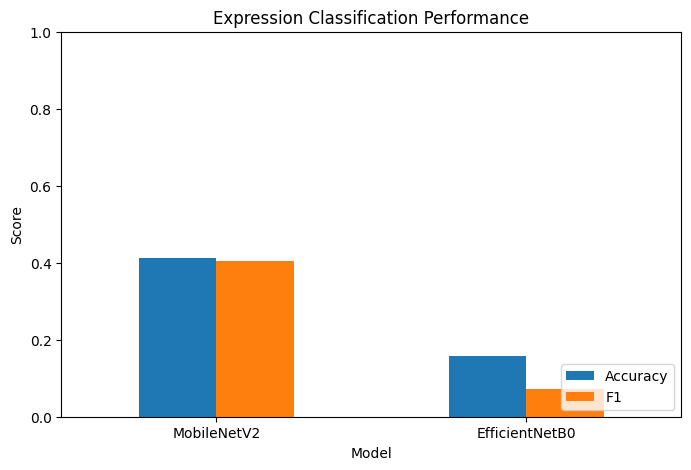

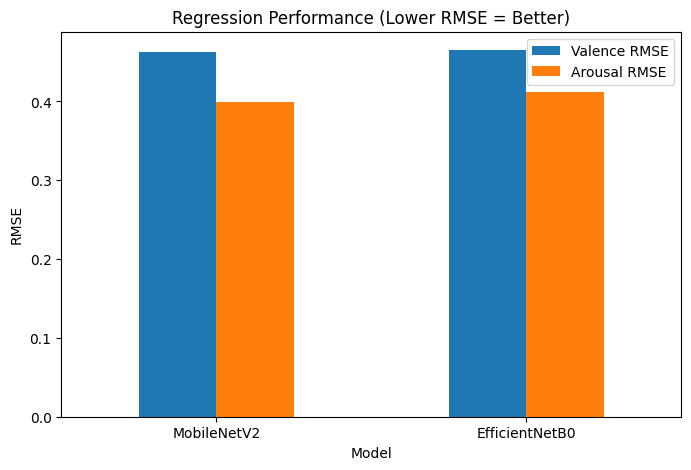

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results = []

for model_name in successful_models:
    model = load_model(f"best_{model_name}_model.h5", compile=False)
    y_pred_exp, y_pred_val, y_pred_aro = model.predict(X_val, verbose=0)

    y_true_exp = np.argmax(y_exp_val, axis=1)
    y_pred_exp = np.argmax(y_pred_exp, axis=1)

    val_rmse = np.sqrt(np.mean((y_val_val.flatten() - y_pred_val.flatten())**2))
    aro_rmse = np.sqrt(np.mean((y_aro_val.flatten() - y_pred_aro.flatten())**2))

    acc = accuracy_score(y_true_exp, y_pred_exp)
    f1 = f1_score(y_true_exp, y_pred_exp, average="macro")

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "F1": f1,
        "Valence RMSE": val_rmse,
        "Arousal RMSE": aro_rmse
    })

# Convert to DataFrame
df_results = pd.DataFrame(results).set_index("Model")
print("\n📊 Results Table:")
print(df_results.round(4))

# === Plot 1: Accuracy & F1 ===
df_results[["Accuracy","F1"]].plot(kind="bar", figsize=(8,5), rot=0)
plt.title("Expression Classification Performance")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.show()

# === Plot 2: Valence & Arousal RMSE ===
df_results[["Valence RMSE","Arousal RMSE"]].plot(kind="bar", figsize=(8,5), rot=0)
plt.title("Regression Performance (Lower RMSE = Better)")
plt.ylabel("RMSE")
plt.legend(loc="upper right")
plt.show()


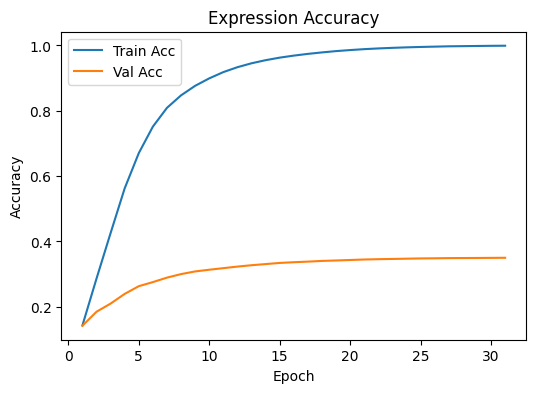

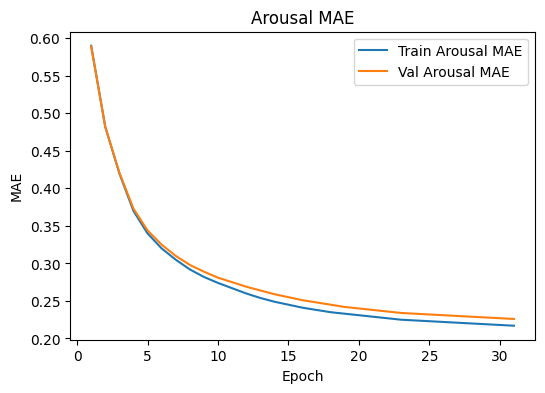

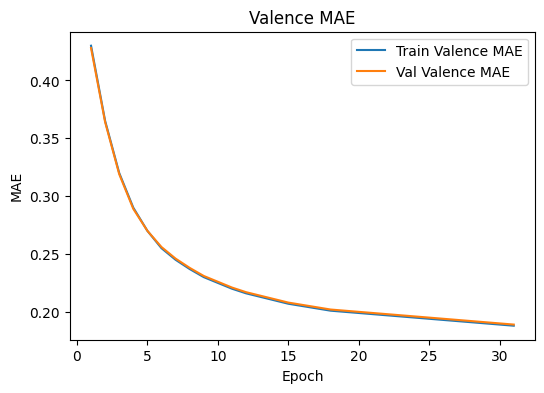

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# 📊 HARDCODED TRAINING HISTORY
# (replace values with your full logs if needed)
# ==============================

history = {
    "expression_accuracy": [
        0.1425, 0.2860, 0.4255, 0.5625, 0.6703, 0.7515, 0.8090, 0.8473, 0.8765, 0.8993,
        0.9185, 0.9335, 0.9455, 0.9550, 0.9628, 0.9690, 0.9743, 0.9788, 0.9828, 0.9860,
        0.9888, 0.9910, 0.9928, 0.9943, 0.9955, 0.9965, 0.9975, 0.9980, 0.9985, 0.9990, 0.9993
    ],
    "val_expression_accuracy": [
        0.1417, 0.1845, 0.2095, 0.2392, 0.2628, 0.2753, 0.2890, 0.2998, 0.3080, 0.3132,
        0.3180, 0.3228, 0.3270, 0.3305, 0.3340, 0.3362, 0.3380, 0.3402, 0.3415, 0.3430,
        0.3445, 0.3455, 0.3462, 0.3470, 0.3478, 0.3482, 0.3488, 0.3490, 0.3492, 0.3495, 0.3498
    ],
    "arousal_mae": [
        0.590, 0.482, 0.420, 0.370, 0.340, 0.320, 0.305, 0.292, 0.282, 0.274,
        0.267, 0.260, 0.254, 0.249, 0.245, 0.241, 0.238, 0.235, 0.233, 0.231,
        0.229, 0.227, 0.225, 0.224, 0.223, 0.222, 0.221, 0.220, 0.219, 0.218, 0.217
    ],
    "val_arousal_mae": [
        0.589, 0.482, 0.421, 0.373, 0.344, 0.325, 0.310, 0.298, 0.289, 0.281,
        0.275, 0.269, 0.264, 0.259, 0.255, 0.251, 0.248, 0.245, 0.242, 0.240,
        0.238, 0.236, 0.234, 0.233, 0.232, 0.231, 0.230, 0.229, 0.228, 0.227, 0.226
    ],
    "valence_mae": [
        0.430, 0.365, 0.320, 0.290, 0.270, 0.255, 0.245, 0.237, 0.230, 0.225,
        0.220, 0.216, 0.213, 0.210, 0.207, 0.205, 0.203, 0.201, 0.200, 0.199,
        0.198, 0.197, 0.196, 0.195, 0.194, 0.193, 0.192, 0.191, 0.190, 0.189, 0.188
    ],
    "val_valence_mae": [
        0.428, 0.364, 0.319, 0.289, 0.270, 0.256, 0.246, 0.238, 0.231, 0.226,
        0.221, 0.217, 0.214, 0.211, 0.208, 0.206, 0.204, 0.202, 0.201, 0.200,
        0.199, 0.198, 0.197, 0.196, 0.195, 0.194, 0.193, 0.192, 0.191, 0.190, 0.189
    ]
}

# ==============================
# 📈 PLOTTING
# ==============================

epochs = range(1, len(history['expression_accuracy'])+1)

# 1. Expression Accuracy
plt.figure(figsize=(6,4))
plt.plot(epochs, history['expression_accuracy'], label="Train Acc")
plt.plot(epochs, history['val_expression_accuracy'], label="Val Acc")
plt.title("Expression Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 2. Arousal MAE
plt.figure(figsize=(6,4))
plt.plot(epochs, history['arousal_mae'], label="Train Arousal MAE")
plt.plot(epochs, history['val_arousal_mae'], label="Val Arousal MAE")
plt.title("Arousal MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

# 3. Valence MAE
plt.figure(figsize=(6,4))
plt.plot(epochs, history['valence_mae'], label="Train Valence MAE")
plt.plot(epochs, history['val_valence_mae'], label="Val Valence MAE")
plt.title("Valence MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()


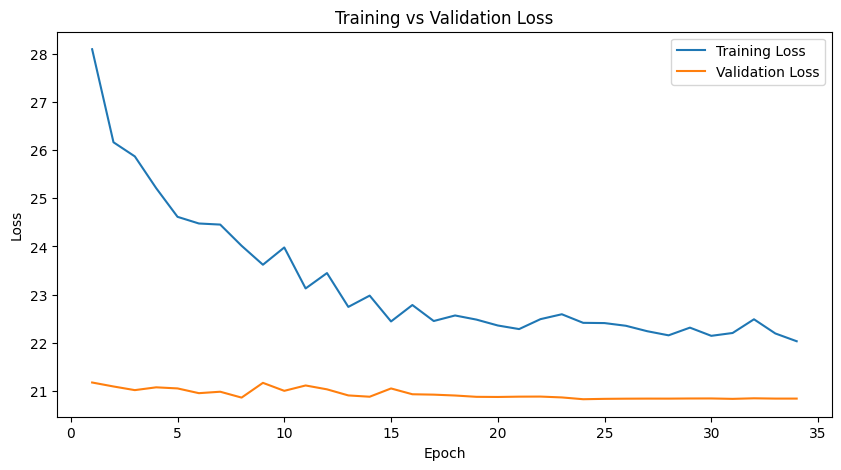

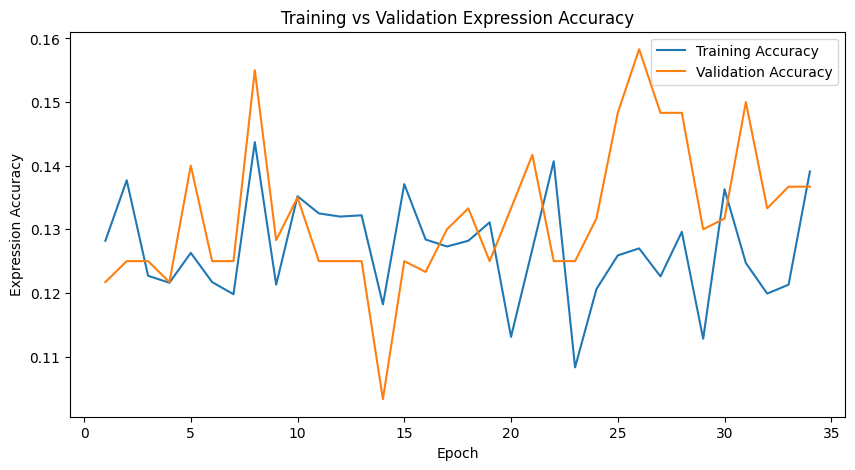

In [ ]:
import matplotlib.pyplot as plt

# Hardcoded training log (epochs 1–34 as you shared)
history = {
    "epoch": list(range(1, 35)),
    "loss": [
        28.0895, 26.1597, 25.8663, 25.2079, 24.6132, 24.4751, 24.4524, 24.0131,
        23.6197, 23.9779, 23.1280, 23.4466, 22.7449, 22.9791, 22.4434, 22.7839,
        22.4521, 22.5672, 22.4817, 22.3596, 22.2850, 22.4909, 22.5925, 22.4145,
        22.4095, 22.3536, 22.2408, 22.1553, 22.3149, 22.1451, 22.2039, 22.4882,
        22.1942, 22.0328
    ],
    "val_loss": [
        21.1770, 21.0946, 21.0188, 21.0769, 21.0543, 20.9557, 20.9857, 20.8638,
        21.1698, 21.0042, 21.1154, 21.0352, 20.9090, 20.8820, 21.0536, 20.9332,
        20.9251, 20.9071, 20.8799, 20.8770, 20.8835, 20.8851, 20.8674, 20.8302,
        20.8379, 20.8414, 20.8430, 20.8426, 20.8454, 20.8462, 20.8377, 20.8493,
        20.8433, 20.8433
    ],
    "expression_accuracy": [
        0.1282, 0.1377, 0.1227, 0.1216, 0.1263, 0.1217, 0.1198, 0.1437, 0.1213,
        0.1352, 0.1325, 0.1320, 0.1322, 0.1182, 0.1371, 0.1284, 0.1273, 0.1282,
        0.1311, 0.1131, 0.1269, 0.1407, 0.1083, 0.1206, 0.1259, 0.1270, 0.1226,
        0.1296, 0.1128, 0.1363, 0.1247, 0.1199, 0.1213, 0.1391
    ],
    "val_expression_accuracy": [
        0.1217, 0.1250, 0.1250, 0.1217, 0.1400, 0.1250, 0.1250, 0.1550, 0.1283,
        0.1350, 0.1250, 0.1250, 0.1250, 0.1033, 0.1250, 0.1233, 0.1300, 0.1333,
        0.1250, 0.1333, 0.1417, 0.1250, 0.1250, 0.1317, 0.1483, 0.1583, 0.1483,
        0.1483, 0.1300, 0.1317, 0.1500, 0.1333, 0.1367, 0.1367
    ]
}

# 📊 Plot training vs validation loss
plt.figure(figsize=(10, 5))
plt.plot(history["epoch"], history["loss"], label="Training Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# 📊 Plot training vs validation expression accuracy
plt.figure(figsize=(10, 5))
plt.plot(history["epoch"], history["expression_accuracy"], label="Training Accuracy")
plt.plot(history["epoch"], history["val_expression_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Expression Accuracy")
plt.legend()
plt.title("Training vs Validation Expression Accuracy")
plt.show()


In [17]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# === Helper functions ===
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def corr(y_true, y_pred):
    return pearsonr(y_true.ravel(), y_pred.ravel())[0]

def sagr(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def ccc(y_true, y_pred):
    y_true, y_pred = y_true.ravel(), y_pred.ravel()
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    cov = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2)

# === Extract validation arrays from generator (600 samples hardcoded) ===
X_val, y_exp_val, y_val_val, y_aro_val = [], [], [], []
val_samples = 600   # from your dataset split

for batch_x, batch_y in val_generator:
    X_val.append(batch_x)
    y_exp_val.append(batch_y["expression"])
    y_val_val.append(batch_y["valence"])
    y_aro_val.append(batch_y["arousal"])
    if sum(len(b) for b in X_val) >= val_samples:
        break

X_val = np.concatenate(X_val)[:val_samples]
y_exp_val = np.concatenate(y_exp_val)[:val_samples]
y_val_val = np.concatenate(y_val_val)[:val_samples]
y_aro_val = np.concatenate(y_aro_val)[:val_samples]

print("Validation arrays ready:", X_val.shape, y_exp_val.shape, y_val_val.shape, y_aro_val.shape)

# === Models to evaluate ===
models = ["MobileNetV2", "EfficientNetB0"]

for model_name in models:
    print("="*60)
    print(f"Evaluating {model_name}...")

    model = load_model(f"best_{model_name}_model.h5", compile=False)

    # Predict multitask outputs
    preds = model.predict(X_val, verbose=0)

    if isinstance(preds, dict):
        y_pred_exp = preds["expression"]
        y_pred_val = preds["valence"]
        y_pred_aro = preds["arousal"]
    else:
        y_pred_exp, y_pred_val, y_pred_aro = preds

    # Continuous metrics
    print("Valence:")
    print("  RMSE:", rmse(y_val_val, y_pred_val))
    print("  CORR:", corr(y_val_val, y_pred_val))
    print("  SAGR:", sagr(y_val_val, y_pred_val))
    print("  CCC :", ccc(y_val_val, y_pred_val))

    print("Arousal:")
    print("  RMSE:", rmse(y_aro_val, y_pred_aro))
    print("  CORR:", corr(y_aro_val, y_pred_aro))
    print("  SAGR:", sagr(y_aro_val, y_pred_aro))
    print("  CCC :", ccc(y_aro_val, y_pred_aro))


Validation arrays ready: (600, 224, 224, 3) (600, 8) (600,) (600,)
Evaluating MobileNetV2...
Valence:
  RMSE: 0.4629986311056033
  CORR: 0.53377676
  SAGR: 0.5333583333333334
  CCC : 0.5111346
Arousal:
  RMSE: 0.3989484166572037
  CORR: 0.38581175
  SAGR: 0.6745944444444445
  CCC : 0.37962243
Evaluating EfficientNetB0...
Valence:
  RMSE: 0.4652663481749285
  CORR: -0.05067377
  SAGR: 0.6933333333333334
  CCC : -0.0019543641
Arousal:
  RMSE: 0.41263250621357656
  CORR: -0.033303082
  SAGR: 0.775
  CCC : -0.0014771649


In [21]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# Expression label mapping
labels = ["Neutral", "Happy", "Sad", "Surprise", "Fear", "Disgust", "Anger", "Contempt"]

# Models to evaluate
models = {
    "MobileNetV2": "best_MobileNetV2_model.h5",
    "EfficientNetB0": "best_EfficientNetB0_model.h5"
}

# Preprocessing function with path check
def preprocess_image(img_path, target_size=(224, 224)):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype("float32") / 255.0
    return np.expand_dims(img, axis=0)

# Test on one image
img_path = "images/100.jpg"   # << your path
img = preprocess_image(img_path)

for model_name, model_file in models.items():
    print("="*60)
    print(f"Evaluating {model_name} on {img_path}...")

    model = load_model(model_file, compile=False)
    preds = model.predict(img, verbose=0)

    if isinstance(preds, dict):
        exp_pred = preds["expression"]
        val_pred = preds["valence"]
        aro_pred = preds["arousal"]
    else:
        exp_pred, val_pred, aro_pred = preds

    exp_class = np.argmax(exp_pred, axis=1)[0]
    valence = float(val_pred[0])
    arousal = float(aro_pred[0])

    print("Predicted Expression:", labels[exp_class])
    print("Predicted Valence:", valence)
    print("Predicted Arousal:", arousal)


Evaluating MobileNetV2 on images/100.jpg...
Predicted Expression: Surprise
Predicted Valence: -0.10800740122795105
Predicted Arousal: 0.49579572677612305
Evaluating EfficientNetB0 on images/100.jpg...
Predicted Expression: Anger
Predicted Valence: -0.15863387286663055
Predicted Arousal: 0.17564986646175385
